# SoLID PID trianing notebook

google colab script to train models for particle identification in SoLID

SoLID is a nuclear physics detector at  Jefferson Lab https://solid.jlab.org

Author: Zhiwen Zhao, Kishansingh Rajput

# prepare env

In [1]:
%%script echo skipping

# use modin as a drop-in replacement for pandas with multi-thread and memory disk cache
# even though it needs about 10GB more mem, it reduce speed of reading 1e6 csv into pandas from 9m to 3m, but increase train_test_split speed from 1m to 6m
!pip install "modin[all]"

# import os
# os.environ["MODIN_ENGINE"] = "ray"  # Modin will use Ray
# os.environ["MODIN_ENGINE"] = "dask"  # Modin will use Dask
# os.environ["MODIN_ENGINE"] = "unidist" # Modin will use Unidist
# os.environ["UNIDIST_BACKEND"] = "mpi" # Unidist will use MPI backend

skipping


In [2]:
import os.path
import math
import numpy as np
import pandas as pd
# import modin.pandas as pd # use modin instead of pandas
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings
# from suf_sns.visualization.ML_vis import plt_metric, getSeparationPlot, getROC
# import solid.models.models

In [3]:
print("TensorFlow version:", tf.__version__)

# !cat /proc/cpuinfo
# !cat /proc/meminfo

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

# Check the number of available GPUs
gpu_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpu_devices))
if len(gpu_devices) > 0:
    print("Found GPU at: {}".format(gpu_devices[0].name))
else:
    print("No GPU found. Check runtime settings.")

from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

TensorFlow version: 2.19.0
Sat Apr 25 03:00:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   43C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------------

# define function

In [4]:
# def get_custom_model_v0(inp_shape=54):
def get_custom_model_v0(inp_shape=tuple([54])):
    # Kishan's MLP model
    inp = Input(shape=inp_shape)
    hidden = Dense(256, activation="relu")(inp)
    hidden = BatchNormalization()(hidden)
    hidden = Dropout(0.15)(hidden)
    hidden = Dense(128, activation="relu")(hidden)
    hidden = BatchNormalization()(hidden)
    hidden = Dropout(0.15)(hidden)
    hidden = Dense(128, activation="relu")(hidden)
    hidden = BatchNormalization()(hidden)
    hidden = Dropout(0.15)(hidden)
    hidden = Dense(64, activation="relu")(hidden)
    hidden = BatchNormalization()(hidden)
    hidden = Dropout(0.15)(hidden)
    hidden = Dense(32, activation="relu")(hidden)
    hidden = BatchNormalization()(hidden)
    hidden = Dropout(0.15)(hidden)
    hidden = Dense(16, activation="relu")(hidden)
    hidden = BatchNormalization()(hidden)
    hidden = Dropout(0.15)(hidden)
    out = Dense(1, activation="sigmoid")(hidden)

    # my simple MLP model
    # inp = Input(shape=inp_shape)
    # out1 = Dense(64, activation="relu")(inp)
    # out2 = Dense(32, activation="relu")(out1)
    # out3 = Dense(16, activation="relu")(out2)
    # out = Dense(1, activation="sigmoid")(out3)

    model = tf.keras.models.Model(inputs=inp, outputs=out)

    return model

def plt_metric(history, metric, title, has_valid=True, saveloc=None):
    """Plots the given 'metric' from 'history'.
    Arguments:
        history: history attribute of History object returned from Model.fit.
        metric: Metric to plot, a string value present as key in 'history'.
        title: A string to be used as title of plot.
        has_valid: Boolean, true if valid data was passed to Model.fit else false.
    Returns:
        None.
    """
    plt.plot(history[metric])
    if has_valid:
        plt.plot(history["val_" + metric])
        plt.legend(["train", "validation"], loc="upper left")
    plt.title(title)
    plt.ylabel(metric)
    plt.xlabel("epoch")
    plt.yscale("log")
    if saveloc is not None:
        plt.savefig(saveloc)
    plt.show()


def getSeparationPlot(labels, pred, label="Test set", ylimit=None, saveloc=None):
    import matplotlib.pyplot as plt
    plt.clf()
    fig= plt.figure(2,figsize=(6,4),dpi=100)
    bad_list = np.array([pred[i] for i in range(len(pred)) if labels[i] == 1])
    good_list = np.array([pred[i] for i in range(len(pred)) if labels[i] == 0])
    print('good_list',len(good_list))
    print('bad_list',len(bad_list))
    # plt.hist(good_list, bins=100, label='normal')
    # plt.hist(bad_list, bins=100, alpha=0.75,label='anomalous')
    plt.hist(good_list, bins=100, label='tag 0')
    plt.hist(bad_list, bins=100, alpha=0.75,label='tag 1')
    plt.legend()
    plt.title(label)
    plt.xlabel('Classifier Output')
    plt.ylabel('Entries')
    plt.yscale('log')
    if ylimit != None:
        plt.ylim(ylimit[0], ylimit[1])
    if saveloc is not None:
        plt.savefig(saveloc)
    plt.show()


def getROC(labels, predictions, names, xlimit=[0, 1], ylimit=[0, 1], saveloc=None):
    plt.clf()
    fig= plt.figure(figsize=(8,6),dpi=100)
    from sklearn.metrics import roc_curve, roc_auc_score
    for i in range(len(labels)):
        # lr_fpr_train, lr_tpr_train, _ = roc_curve(labels[i], predictions[i])
        lr_fpr_train, lr_tpr_train, threshold = roc_curve(labels[i], predictions[i])
        auc_train = roc_auc_score(labels[i], predictions[i])
        plt.plot(lr_fpr_train, lr_tpr_train, linewidth=1.5, label=names[i]+" AUC:"+str(np.round(auc_train, 4)))
        # print(threshold[(lr_fpr_train<0.05 && lr_tpr_train>0.95)])
        # print(threshold[(lr_tpr_train>0.95)])
    # axis labels
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.grid(color='gray', linestyle='--', linewidth=1)
    plt.legend()
    ident = [0.0, 1.0]
    plt.plot(ident,ident, ls='--')
    plt.xlim(xlimit)
    plt.ylim(ylimit)
    if saveloc is not None:
        plt.savefig(saveloc)
    plt.show()

In [5]:
warnings.filterwarnings("ignore")
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.labelweight'] = 'regular'
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['font.family'] = [u'serif']
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = 14, 10


# download file

In [6]:
# %%script echo skipping

# modify here to change hgc files

downloadfile=True
# downloadfile=False

# web="https://solid.jlab.org/files/AIML/"
web="https://www.phy.duke.edu/~zz81/AIML/"

# old simulation
# setup="solid_hgc_sim/"
# filepre="solid_SIDIS_He3_hgc_moved_"

# dir="backgroundno/"
# dir="background3sector/"
# dir="background3sectordouble/"

# dir="backgroundno_nodecay/"
# dir="background3sector_nodecay/"
# dir="background3sectordouble_nodecay/"

# new simulation
# setup="solid_hgc_sim_full/"
# filepre="solid_SIDIS_He3_hgc_moved_full"

setup="solid_SIDIS_He3_full_hgc/"
filepre="solid_SIDIS_He3_moved_full_"

# dir="backgroundno_nodecaytrack/"
# dir="background3sector_nodecaytrack/"
dir="background3sectordouble_nodecaytrack/"

# filekinematics="_z350_p2.5_theta8.0_1e6_row_"
# filekinematics="_z350_p7.5_theta14.5_1e6_row_"
filekinematics="_z350cm_p2.5-7.5GeV_theta8-14.5deg_1e6_row_"
# filekinematics="_1e5_row_"

# note smaller readout size has more data and need larger mem to train, but train faster
#number of entry for cherenkov info
# Nsensor=1
# filesensor="npe"
# Nsensor=48
# filesensor="pmt"
Nsensor=192
filesensor="quad"
# Nsensor=3072
# filesensor="pixel"

par1="pim"
par2="km"

url=web+setup+dir+filepre+par1+filekinematics+filesensor+".csv.zip -O par1.csv.zip"
# print(url)
if downloadfile:
# if not os.path.isfile("par1.csv.zip"):
  !wget $url
url=web+setup+dir+filepre+par2+filekinematics+filesensor+".csv.zip -O par2.csv.zip"
# url=web+dir+filepre+"bg"+filekinematics+filesensor+".csv.zip -O par2.csv.zip"
# print(url)
if downloadfile:
# if not os.path.isfile("par2.csv.zip"):
  !wget $url

!ls -lh

--2026-04-25 03:00:36--  https://www.phy.duke.edu/~zz81/AIML/solid_SIDIS_He3_full_hgc/background3sectordouble_nodecaytrack/solid_SIDIS_He3_moved_full_pim_z350cm_p2.5-7.5GeV_theta8-14.5deg_1e6_row_quad.csv.zip
Resolving www.phy.duke.edu (www.phy.duke.edu)... 152.3.103.25
Connecting to www.phy.duke.edu (www.phy.duke.edu)|152.3.103.25|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://physics.duke.edu/~zz81/AIML/solid_SIDIS_He3_full_hgc/background3sectordouble_nodecaytrack/solid_SIDIS_He3_moved_full_pim_z350cm_p2.5-7.5GeV_theta8-14.5deg_1e6_row_quad.csv.zip [following]
--2026-04-25 03:00:38--  http://physics.duke.edu/~zz81/AIML/solid_SIDIS_He3_full_hgc/background3sectordouble_nodecaytrack/solid_SIDIS_He3_moved_full_pim_z350cm_p2.5-7.5GeV_theta8-14.5deg_1e6_row_quad.csv.zip
Resolving physics.duke.edu (physics.duke.edu)... 152.3.103.25
Connecting to physics.duke.edu (physics.duke.edu)|152.3.103.25|:80... connected.
HTTP request sent, awaiting r

In [7]:
# %%script echo skipping

# modify here to change old hgc files

Ntrack=6 #number of entry for track info

# full length of each line, last entry is label (tag 1 for 1st file, tag 0 for 2nd file)
Nentry=Nsensor+Ntrack+1

data_start=0
# data_end=Nsensor+Ntrack # use both hgc and track
# data_end=Nsensor+1 # use both hgc and track partially
data_end=Nsensor # use hgc only

In [8]:
%%script echo skipping

# modify here to change lgc and ec files

downloadfile=True
# downloadfile=False

# filepre="solid_SIDIS_He3_moved_full_"

# setup="solid_SIDIS_He3_full_lgc"
# setup="solid_SIDIS_He3_full_lgcec"
# filekinematics="_z350_p3.0_theta12.0_1e6_row_"
# filekinematics="_z350_p2.5_theta8.0_1e6_row_"
# filekinematics="_z350_p4.5_theta14.5_1e6_row_"

# filepre="solid_PVDIS_LD2_moved_full_"

# setup="solid_PVDIS_LD2_full_lgc"
# setup="solid_PVDIS_LD2_full_lgcec"
# filekinematics="_z10_p2.5_theta22_1e6_row_"
# filekinematics="_z10_p4.5_theta34_1e6_row_"

# par1="ele"
# par2="pim"
# #number of entry for cherenkov info
# # Nsensor=1
# # filesensor="npe"
# Nsensor=27
# filesensor="pmt"
# # Nsensor=108
# # filesensor="quad"
# # Nsensor=1728
# # filesensor="pixel"

#.....................

# dir="backgroundno_nodecaytrack/"
# dir="background3sector_nodecaytrack/"
dir="background3sectordouble_nodecaytrack/"

url=web+dir+filepre+par1+filekinematics+filesensor+".csv.zip -O par1.csv.zip"
# print(url)
if downloadfile:
# if not os.path.isfile("par1.csv.zip"):
  !wget $url
url=web+dir+filepre+par2+filekinematics+filesensor+".csv.zip -O par2.csv.zip"
# url=web+dir+filepre+"bg"+filekinematics+filesensor+".csv.zip -O par2.csv.zip"
# print(url)
if downloadfile:
# if not os.path.isfile("par2.csv.zip"):
  !wget $url

!ls -lh

skipping


In [9]:
%%script echo skipping

# modify here to change lgc and ec files

Ntrack=6 #number of entry for track info

#number of entry for EC info
# Necmodule=0  # for lgc only file
Necmodule=19*2  # for lgc+ec file

# full length of each line, last entry is label (tag 1 for 1st file, tag 0 for 2nd file)
Nentry=Nsensor+Ntrack+Necmodule+1

data_start=0
# data_start=Nsensor+Ntrack # use ec only
# data_end=Nsensor+Ntrack+Necmodule  # use lgc and track and EC
data_end=Nsensor+Ntrack # use lgc and track
# data_end=Nsensor # use lgc only

skipping


# load data

In [10]:
# par1_data_original = pd.read_csv("par1.csv.zip", header=None) #default is float64
# par2_data_original = pd.read_csv("par2.csv.zip", header=None) #default is float64
# par1_data_original = pd.read_csv("par1.csv.zip", header=None,dtype="float32")
# par2_data_original = pd.read_csv("par2.csv.zip", header=None,dtype="float32")
par1_data_original = pd.read_csv("par1.csv.zip", header=None,dtype="float16")
par2_data_original = pd.read_csv("par2.csv.zip", header=None,dtype="float16")


# par1_data = pd.read_csv("par1.csv.gz", header=None)
# par2_data = pd.read_csv("par2.csv.gz", header=None)
# par1_data = pd.read_csv("par1.csv.gz", header=None,dtype="float32")
# par2_data = pd.read_csv("par2.csv.gz", header=None,dtype="float32")

# par2_data = pd.read_csv("/group/solid/www/solid/html/files/AIML/solid_hgc_sim/background3sector_nodecaytrack/solid_SIDIS_He3_hgc_moved_km_z350_p2.5_theta8.0_1e5_row_pmt.csv.zip", header=None)
# par1_data = pd.read_csv("/group/solid/www/solid/html/files/AIML/solid_hgc_sim/background3sector_nodecaytrack/solid_SIDIS_He3_hgc_moved_pim_z350_p2.5_theta8.0_1e5_row_pmt.csv.zip", header=None)

# !wget https://solid.jlab.org/files/AIML/solid_hgc_sim/background3sector_nodecaytrack/solid_SIDIS_He3_hgc_moved_pim_z350_p2.5_theta8.0_1e5_row_pmt.csv.zip -O pion.csv.zip
# !wget https://solid.jlab.org/files/AIML/solid_hgc_sim/background3sector_nodecaytrack/solid_SIDIS_He3_hgc_moved_km_z350_p2.5_theta8.0_1e5_row_pmt.csv.zip -O kaon.csv.zip

In [11]:
# Select the first portion of data
portion = 1
# portion = 0.1

par1_data = par1_data_original.iloc[:int(len(par1_data_original) * portion)]
par2_data = par2_data_original.iloc[:int(len(par2_data_original) * portion)]

# Select the first portion of data, but hard copy take more mem
# par1_data = par1_data_original.iloc[:int(len(par1_data_original) * portion)].copy(deep=True)
# par2_data = par2_data_original.iloc[:int(len(par2_data_original) * portion)].copy(deep=True)

# check data

In [12]:
# par1_data.dtypes
# par2_data.dtypes

In [13]:
# par1_data.memory_usage(deep=True)
# par2_data.memory_usage(deep=True)

In [14]:
display(par1_data)
display(par2_data)

,0,1,2,3,4,5,6,7,8,9,...,189,190,191,192,193,194,195,196,197,198
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.997070,-0.864258,6.359375,96.625000,-98.3750,313.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.750488,-1.328125,6.578125,67.062500,-138.7500,313.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.706543,-0.639160,4.722656,88.625000,-101.1875,313.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.201660,-0.956055,5.468750,-38.187500,-112.3750,313.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.207397,0.687500,3.500000,57.937500,124.6875,313.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
934548,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.691895,0.468750,5.082031,98.500000,46.1875,313.0,1.0
934549,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.368408,-1.126953,4.902344,38.750000,-157.1250,313.0,1.0
934550,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.041290,-0.595215,3.253906,-15.273438,-120.6250,313.0,1.0
934551,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.129883,-0.983887,6.542969,108.750000,-107.1875,313.0,1.0


,0,1,2,3,4,5,6,7,8,9,...,189,190,191,192,193,194,195,196,197,198
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.323975,0.226440,2.525391,-55.156250,81.875000,313.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.276367,1.012695,5.156250,49.093750,126.625000,313.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.041718,-1.270508,6.062500,-15.500000,-138.750000,313.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.051605,0.827637,5.339844,23.578125,99.187500,313.0,0.0
4,5.0,5.0,1.0,6.0,5.0,2.0,2.0,0.0,1.0,3.0,...,0.0,0.0,0.0,0.012360,-0.547852,2.544922,-23.140625,-144.125000,313.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789293,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.686523,-0.058380,3.132812,-147.750000,8.570312,313.0,0.0
789294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.732422,-0.542969,4.101562,109.687500,-100.937500,313.0,0.0
789295,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.763672,0.873047,5.218750,-88.500000,119.437500,313.0,0.0
789296,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.134277,-1.286133,5.718750,4.855469,-150.875000,313.0,0.0


In [15]:
%%script echo skipping

# prompt: sum  0-19 columns and 20-38 columns of par1_data, then plot them against each other
# for EC only
if data_start==Nsensor+Ntrack:
  par1_data_sum1 = par1_data.iloc[:, data_start:data_start+38].sum(axis=1)
  par1_data_sum2 = par1_data.iloc[:, data_start:data_start+19].sum(axis=1)
  # plt.scatter(par1_data_sum1, par1_data_sum2)
  plt.hist2d(par1_data_sum1, par1_data_sum2, bins=100, cmin=0.5, cmap='viridis')
  plt.colorbar()
  plt.ylabel("EC preshower")
  plt.xlabel("EC pershower+shower")
  plt.show()

skipping


In [16]:
%%script echo skipping

# prompt: sum  0-19 columns and 20-38 columns of par2_data, then plot them against each other
# for EC only
if data_start==Nsensor+Ntrack:
  par2_data_sum1 = par2_data.iloc[:, data_start:data_start+38].sum(axis=1)
  par2_data_sum2 = par2_data.iloc[:, data_start:data_start+19].sum(axis=1)
  # plt.scatter(par1_data_sum1, par1_data_sum2)
  plt.hist2d(par2_data_sum1, par2_data_sum2, bins=100, cmin=0.5, cmap='viridis')
  plt.colorbar()
  plt.ylabel("EC preshower")
  plt.xlabel("EC pershower+shower")
  plt.show()

skipping


In [17]:
%%script echo skipping

# prompt: add two scatter plot together
if data_start==Nsensor+Ntrack:
  plt.scatter(par1_data_sum1, par1_data_sum2, label="par1")
  plt.scatter(par2_data_sum1, par2_data_sum2, label="par2")
  plt.legend()
  plt.ylabel("EC preshower")
  plt.xlabel("EC pershower+shower")
  plt.show()

skipping


In [18]:
# mat_pion = par1_data.to_numpy()
# mat_pion.shape
# m_pion=mat_pion[:, :Nsensor]
# m_pion.shape

In [19]:
# for i in range(3):
#   # plt.imshow(m_kaon[i][:, :Nsensor-1].reshape(12,4))
#   plt.imshow(m_pion[i].reshape(int(math.sqrt(Nsensor/3)),3*int(math.sqrt(Nsensor/3))))
#   plt.show()

#prepare data

In [20]:
# combine par1 and par2 data and shuffle them
data = pd.concat([par1_data, par2_data])

#  use par1 data only without shuffle
# data = pd.concat([par1_data])

In [21]:
# data = shuffle(data) // train_test_split will do the shuffle instead

In [22]:
%%script echo skipping

data_sum1 = data.iloc[:, data_start:data_start+38].sum(axis=1)
data_sum2 = data.iloc[:, data_start:data_start+19].sum(axis=1)
if data_start==Nsensor+Ntrack:
  plt.hist2d(data_sum1, data_sum2, bins=100, cmin=0.5, cmap='viridis')
  plt.colorbar()
  plt.ylabel("EC preshower")
  plt.xlabel("EC pershower+shower")
  plt.show()

skipping


In [23]:
# %%script echo skipping

# prepare data before training

#normalize data to 0-1
scaler = MinMaxScaler()
data = scaler.fit_transform(data)  # also transfer from pandas to numpy
print(data.min(), data.max())

# select all columns and split data
# train_data, test_data, train_labels, test_labels = train_test_split(data[:, :-1], data[:, -1], test_size=0.25, random_state=42)

# select some columns and split data
train_data, test_data, train_labels, test_labels = train_test_split(data[:, data_start:data_end], data[:, -1], test_size=0.25, random_state=42)
train_data, valid_data, train_labels, valid_labels = train_test_split(train_data, train_labels, test_size=0.33, random_state=42)
# train_data, test_data, train_labels, test_labels = train_test_split(data[:, data_start:data_end], data[:, -1], test_size=0.9, random_state=42)

0.0 1.0


In [24]:
%%script echo skipping
# normalize after split to prevent from leakage

train_data, test_data, train_labels, test_labels = train_test_split(data.iloc[:, data_start:data_end], data.iloc[:, -1], test_size=0.25, random_state=42)

scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data)   # also transfer from pandas to numpy
print(train_data.min(), train_data.max())
test_data = scaler.transform(test_data) # use fit from train_data to normalize test_data
print(test_data.min(), test_data.max())
train_labels = train_labels.to_numpy()
test_labels = test_labels.to_numpy()

skipping


In [25]:
print("Shape: ", data.shape, train_data.shape, train_labels.shape)
display(train_data)
display(train_labels)

Shape:  (1723851, 199) (866234, 192) (866234,)


array([[0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
       ...,
       [0.0833 , 0.     , 0.     , ..., 0.     , 0.     , 0.     ],
       [0.     , 0.02272, 0.04443, ..., 0.     , 0.     , 0.     ],
       [0.1111 , 0.     , 0.     , ..., 0.     , 0.     , 0.     ]],
      dtype=float16)

array([1., 1., 0., ..., 0., 1., 1.], dtype=float16)

In [26]:
%%script echo skipping

#convert data to 2D
data=train_data

nevt=np.size(data,0)
ssen=int(Nsensor/3)
hsen=int(math.sqrt(Nsensor/3))
max_y=hsen
max_x=3*hsen
print("show ",ssen,hsen,max_y,max_x)
mat_data = np.zeros(shape=(nevt,max_y,max_x))

# for evt in range(1):
for evt in range(nevt):
  for i in range(Nsensor):
    # print(i,y,x,i//ssen,i%ssen)
    y=int((i%ssen)%hsen)
    x=int((i%ssen)//hsen+(i//ssen)*hsen)
    mat_data[evt,y,x] = data[evt,i]

  		  # hnpe_hgc_pmt_2D->Fill(index/int(sqrt(Nsensor)),index%int(sqrt(Nsensor)),hit_hgc_pmt[Nsensor*sec_hgc_left+index]);
		    # hnpe_hgc_pmt_2D->Fill(index/int(sqrt(Nsensor))+int(sqrt(Nsensor)),index%int(sqrt(Nsensor)),hit_hgc_pmt[Nsensor*sec_hgc+index]);
		    # hnpe_hgc_pmt_2D->Fill(index/int(sqrt(Nsensor))+2*int(sqrt(Nsensor)),index%int(sqrt(Nsensor)),hit_hgc_pmt[Nsensor*sec_hgc_right+index]);

#plot data to 2D
for i in range(5):
  plt.imshow(mat_data[i])
  plt.show()

skipping


# load/train model

Epoch 1/100
13535/13535 ━━━━━━━━━━━━━━━━━━━━ 60s 4ms/step - accuracy: 0.8959 - loss: 0.2680 - val_accuracy: 0.9333 - val_loss: 0.1736 - learning_rate: 1.0000e-04
Epoch 2/100
13535/13535 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - accuracy: 0.9263 - loss: 0.1942 - val_accuracy: 0.9446 - val_loss: 0.1461 - learning_rate: 1.0000e-04
Epoch 3/100
13535/13535 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 0.9366 - loss: 0.1704 - val_accuracy: 0.9501 - val_loss: 0.1336 - learning_rate: 1.0000e-04
Epoch 4/100
13535/13535 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 0.9435 - loss: 0.1542 - val_accuracy: 0.9546 - val_loss: 0.1244 - learning_rate: 1.0000e-04
Epoch 5/100
13535/13535 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 0.9485 - loss: 0.1435 - val_accuracy: 0.9579 - val_loss: 0.1176 - learning_rate: 1.0000e-04
Epoch 6/100
13535/13535 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 0.9522 - loss: 0.1352 - val_accuracy: 0.9603 - val_loss: 0.1131 - learning_rate: 1.0000e-04
Epoch 7/100
13535/13535 ━━━━

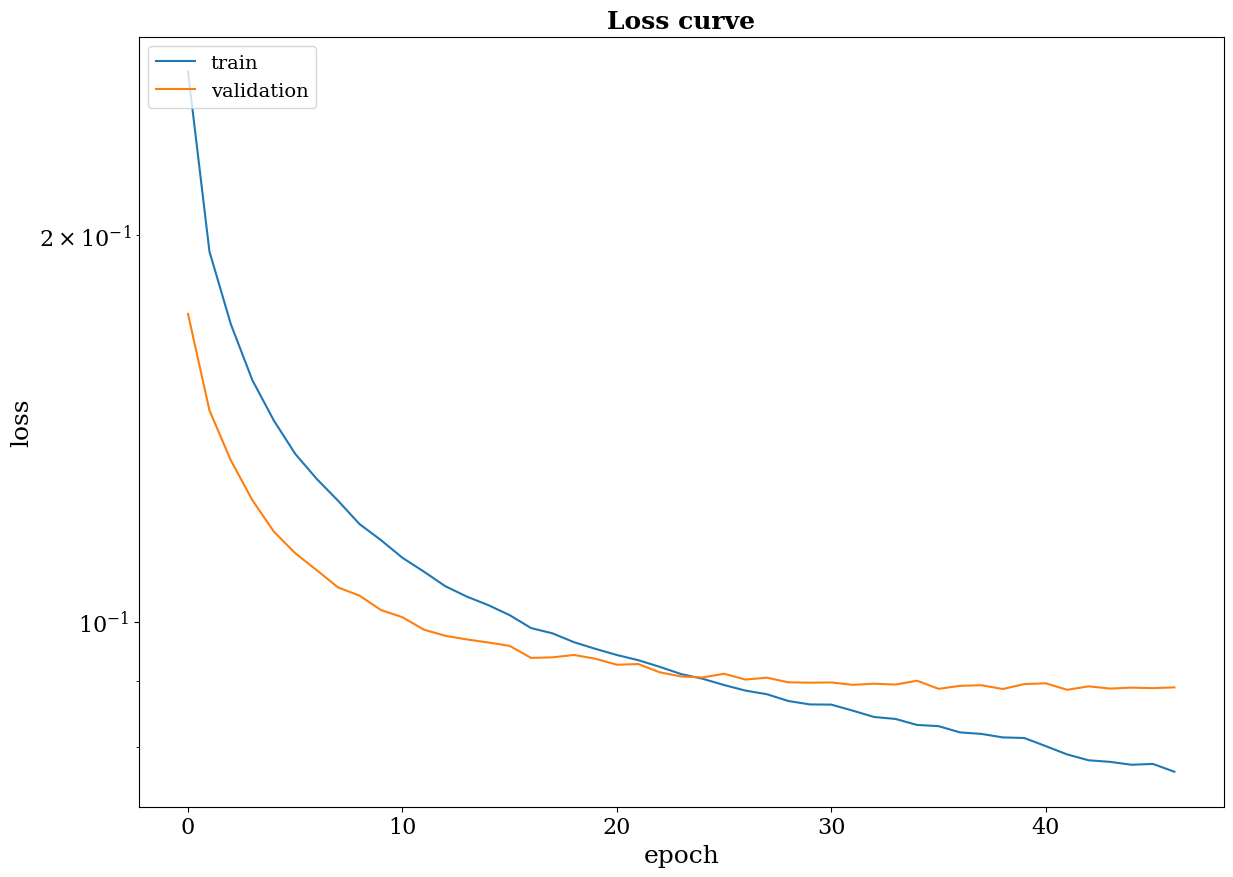

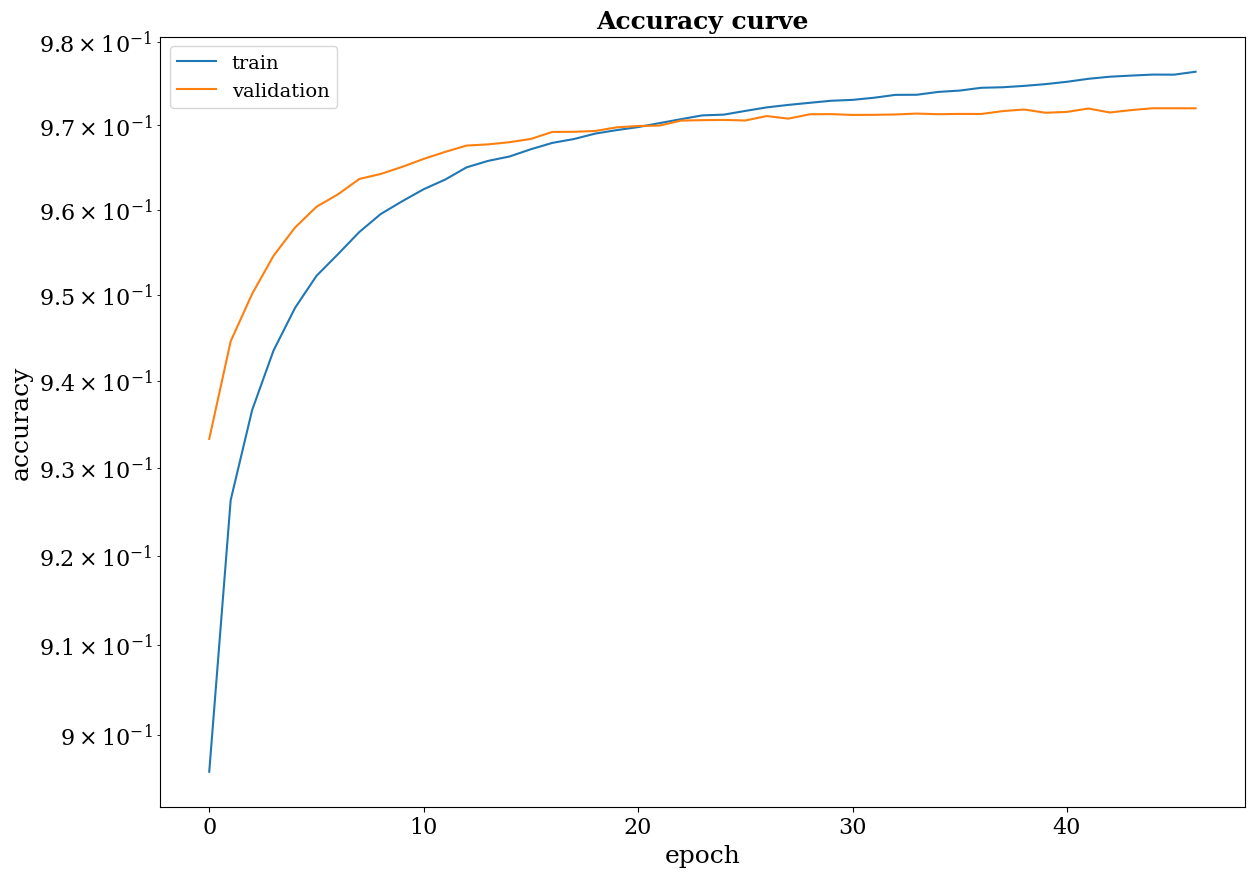

In [27]:
# load model or train a new one

# loadmodel=True
loadmodel=False

if (loadmodel==True):
  model = tf.keras.models.load_model("model.keras")
else:
  # model = get_custom_model_v0()
  model = get_custom_model_v0(inp_shape=tuple([data_end-data_start]))
  # model.summary()

  opt = tf.keras.optimizers.Adam(learning_rate=1e-4) # 1e-5 slow down training by a factor 6, but won't give better result
  model.compile(loss="binary_crossentropy", metrics=['accuracy'], optimizer=opt)

  # reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.85, patience=5, min_lr=1e-6,verbose=1)
  # early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='auto', min_delta=0, patience=30, verbose=1, baseline=None, restore_best_weights=True)

  reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.85, patience=5, min_lr=1e-6,verbose=1)
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='auto', min_delta=0, patience=5, verbose=1, baseline=None, restore_best_weights=True)

  # history = model.fit(train_data, train_labels, epochs=100, batch_size=64, validation_data=(test_data, test_labels),callbacks=[reduce_lr, early_stopping])
  history = model.fit(train_data, train_labels, epochs=100, batch_size=64, validation_data=(valid_data, valid_labels),callbacks=[reduce_lr, early_stopping])

  model.save("model.keras")

  plt_metric(history.history, metric='loss', title='Loss curve', saveloc="loss.png")
  plt.clf()
  plt_metric(history.history, metric='accuracy', title='Accuracy curve', saveloc="acc.png")

# plot results

In [28]:
# make separation and ROC plot
train_preds = model.predict(train_data)
test_preds = model.predict(test_data)
print(train_preds.min(), train_preds.max())
print(test_preds.min(), test_preds.max())

27070/27070 ━━━━━━━━━━━━━━━━━━━━ 38s 1ms/step
13468/13468 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step
0.0003777423 1.0
0.0008172995 0.9999999


good_list 197356
bad_list 233607


<Figure size 1400x1000 with 0 Axes>

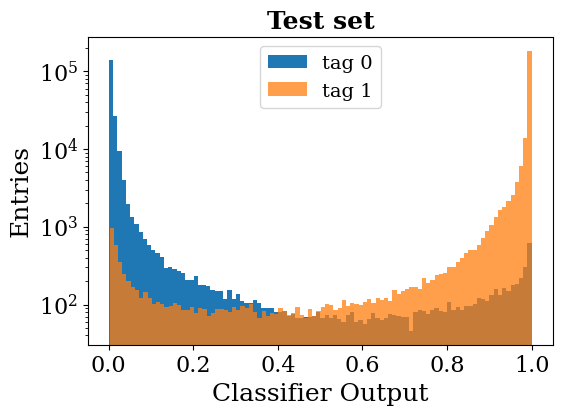

good_list 396643
bad_list 469591


<Figure size 1400x1000 with 0 Axes>

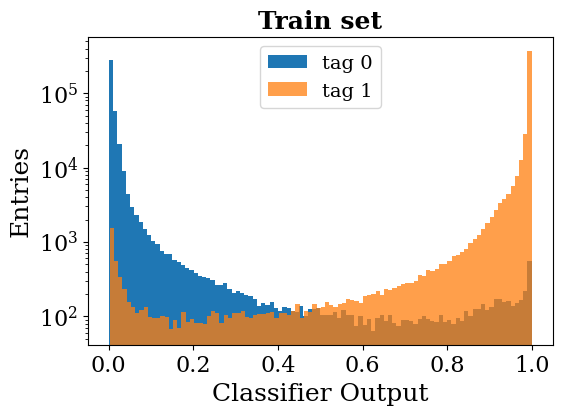

<Figure size 1400x1000 with 0 Axes>

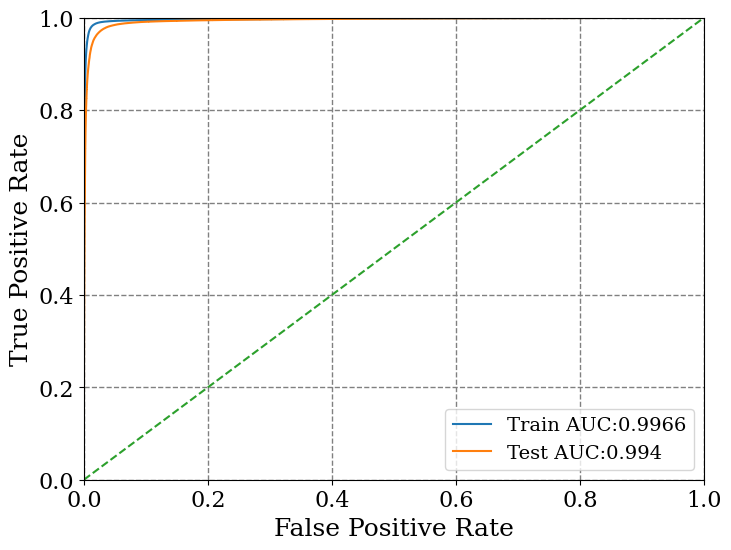

<Figure size 1400x1000 with 0 Axes>

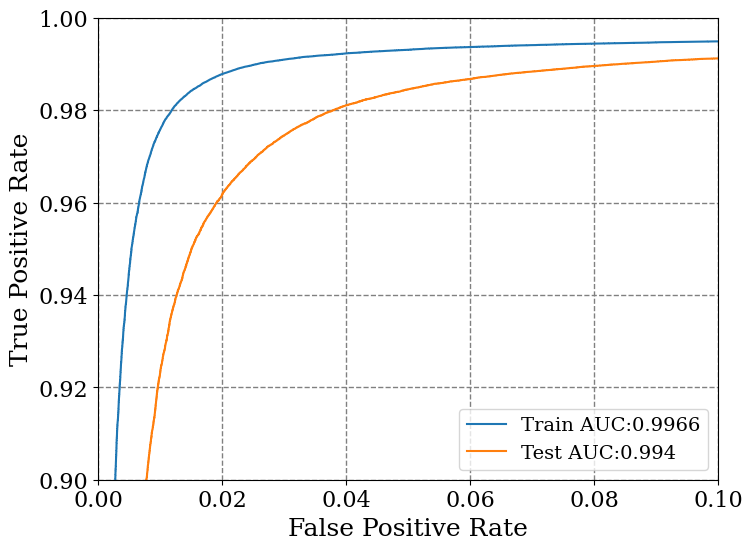

In [29]:
getSeparationPlot(test_labels, test_preds, "Test set", saveloc="Test_separation.png")
getSeparationPlot(train_labels, train_preds, "Train set", saveloc="Train_separation.png")

getROC([train_labels, test_labels], [train_preds, test_preds], ["Train", "Test"], saveloc="ROC.png")
getROC([train_labels, test_labels], [train_preds, test_preds], ["Train", "Test"], saveloc="ROC_zoomin.png",
       xlimit=[0, 0.1], ylimit=[0.9, 1.0])

13468/13468 - 25s - 2ms/step - accuracy: 0.9723 - loss: 0.0868
overall efficiency: 0.9723
tag 1 efficiency: 0.9721
tag 0 efficiency: 0.9726


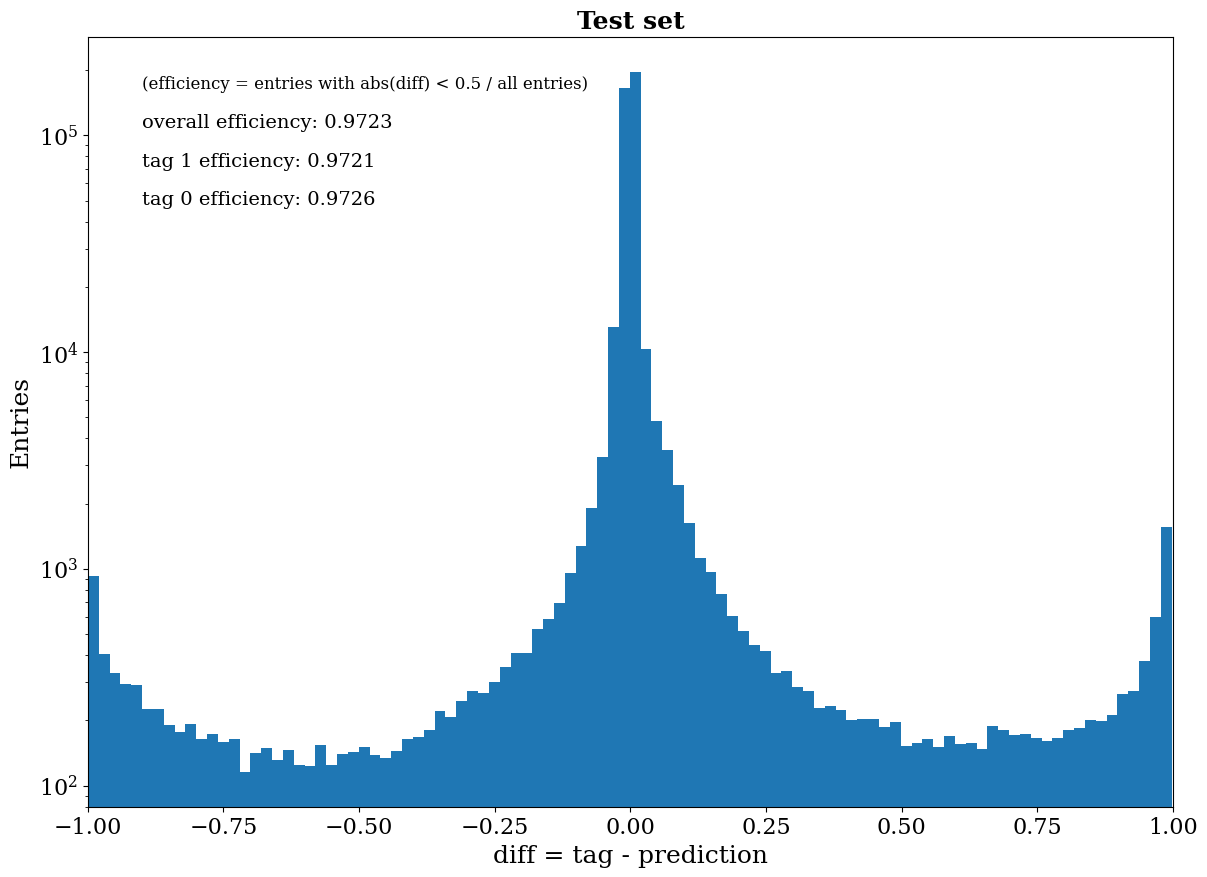

In [30]:
# make efficiency plot
model.evaluate(test_data,  test_labels, verbose=2)

threshold = 0.5

diff = test_labels - test_preds.flatten()
Ngood = abs(diff) < threshold
goodDiff = diff[Ngood]
# plt.hist(goodDiff, bins=100)
plt.hist(diff, bins=100)

efficiency = len(goodDiff)/len(diff)
par1_diff = diff[test_labels == 1]
par2_diff = diff[test_labels == 0]
par1_good_diff = par1_diff[abs(par1_diff) < threshold]
par2_good_diff = par2_diff[abs(par2_diff) < 1-threshold]
efficiency_par1=len(par1_good_diff)/len(par1_diff)
efficiency_par2=len(par2_good_diff)/len(par2_diff)

print(f'overall efficiency: {efficiency:.4f}')
print(f'tag 1 efficiency: {efficiency_par1:.4f}')
print(f'tag 0 efficiency: {efficiency_par2:.4f}')

plt.title("Test set")
plt.xlabel('diff = tag - prediction')
plt.ylabel('Entries')
plt.xlim([-1,1])
plt.yscale('log')

# Add text for accuracies
plt.text(0.05, 0.95, f'(efficiency = entries with abs(diff) < 0.5 / all entries)', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.05, 0.90, f'overall efficiency: {efficiency:.4f}', transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')
plt.text(0.05, 0.85, f'tag 1 efficiency: {efficiency_par1:.4f}', transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')
plt.text(0.05, 0.80, f'tag 0 efficiency: {efficiency_par2:.4f}', transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')

plt.savefig('eff.png')

plt.show()

# save results

In [31]:
!zip a.zip *png *keras

  adding: acc.png (deflated 16%)
  adding: eff.png (deflated 25%)
  adding: loss.png (deflated 14%)
  adding: ROC.png (deflated 9%)
  adding: ROC_zoomin.png (deflated 9%)
  adding: Test_separation.png (deflated 11%)
  adding: Train_separation.png (deflated 11%)
  adding: model.keras (deflated 13%)


In [32]:
!ls -lrth

total 100M
-rw-r--r-- 1 root root  39M Feb  8 00:08 par2.csv.zip
-rw-r--r-- 1 root root  58M Feb  8 00:08 par1.csv.zip
drwxr-xr-x 1 root root 4.0K Apr 16 13:33 sample_data
drwx------ 6 root root 4.0K Apr 25 03:00 drive
-rw-r--r-- 1 root root 1.4M Apr 25 03:37 model.keras
-rw-r--r-- 1 root root  51K Apr 25 03:37 loss.png
-rw-r--r-- 1 root root  65K Apr 25 03:37 acc.png
-rw-r--r-- 1 root root  19K Apr 25 03:38 Test_separation.png
-rw-r--r-- 1 root root  19K Apr 25 03:38 Train_separation.png
-rw-r--r-- 1 root root  58K Apr 25 03:38 ROC.png
-rw-r--r-- 1 root root  62K Apr 25 03:38 ROC_zoomin.png
-rw-r--r-- 1 root root  51K Apr 25 03:39 eff.png
-rw-r--r-- 1 root root 1.5M Apr 25 03:39 a.zip


In [33]:
cp a.zip drive/MyDrive/